<a href="https://colab.research.google.com/github/roger-teixeira-batista/Case-Tecnico-Grupo-Salta-Educacao/blob/main/Case_Grupo_Salta_ONC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Tarefa 1: Conferência da base de avaliadores**

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

**Base de Avaliadores**

In [ ]:
df_base_avaliadores = pd.read_excel("ONC_Base_Candidato (1) (1).xlsx", sheet_name="Base de Avaliadores")

In [ ]:
df_base_avaliadores.head()

,ID Avaliador,Nome Avaliador,Regional,Valor por prova,Salario Recorrente
0,10000000284,Davi Ribeiro,REGIONAL E,35.07,2873.41
1,10000000171,Daiane Melo,REGIONAL B,54.31,1812.60
2,10000000048,Thiago Cardoso,REGIONAL D,74.50,2329.93
3,10000000248,Daiane Ribeiro,REGIONAL D,52.71,3121.44
4,10000000191,Gustavo Costa,REGIONAL B,44.76,2051.81


In [ ]:
df_base_avaliadores.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 400 entries, 0 to 399
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   ID Avaliador        400 non-null    int64  
 1   Nome Avaliador      400 non-null    object 
 2   Regional            400 non-null    object 
 3   Valor por prova     400 non-null    float64
 4   Salario Recorrente  400 non-null    float64
dtypes: float64(2), int64(1), object(2)
memory usage: 15.8+ KB


**Produção de Maio (lotes)**

In [ ]:
df_maio_lotes = pd.read_excel("ONC_Base_Candidato (1) (1).xlsx", sheet_name="Produção de Maio (lotes)")

In [ ]:
df_maio_lotes.head()

,ID Lote,ID Avaliador,Provas Corrigidas,Bonus de complexidade
0,500001,10000000313,9,191.51
1,500002,10000000362,39,25.51
2,500003,10000000080,16,143.48
3,500004,10000000350,17,199.36
4,500005,10000000278,16,11.98


In [ ]:
df_maio_lotes.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 997 entries, 0 to 996
Data columns (total 4 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   ID Lote                997 non-null    int64  
 1   ID Avaliador           997 non-null    int64  
 2   Provas Corrigidas      997 non-null    int64  
 3   Bonus de complexidade  997 non-null    float64
dtypes: float64(1), int64(3)
memory usage: 31.3 KB


**Tratamento de dados**

Conversão do campo **Nome Avaliador** para o tipo texto.

In [ ]:
df_base_avaliadores['Nome Avaliador'] = df_base_avaliadores['Nome Avaliador'].astype(str)

Remoção dos espaços antes e depois de cada nome de avaliador.

In [ ]:
df_base_avaliadores['Nome Avaliador'] = df_base_avaliadores['Nome Avaliador'].str.strip()

Padronização dos nomes dos avaliadores no formato primeira letra maiúscula e as demais minúsculas. Ex.: Pedro Silva

In [ ]:
df_base_avaliadores['Nome Avaliador'] = df_base_avaliadores['Nome Avaliador'].str.title()

Verificação do resultado das transformações.

In [ ]:
df_base_avaliadores['Nome Avaliador'].unique()

array(['Davi Ribeiro', 'Daiane Melo', 'Thiago Cardoso', 'Daiane Ribeiro',
       'Gustavo Costa', 'Jéssica Oliveira', 'Vinícius Pereira',
       'André Silva', 'Eduardo Nascimento', 'Márcio Esteves',
       'Eduardo Silva', 'Leonardo Xavier', 'Letícia Figueiredo',
       'Cristina Araújo', 'Elaine Costa', 'Eduardo Cardoso',
       'Priscila Martins', 'Eduardo Borges', 'Juliana Guimarães',
       'Silvio Ribeiro', 'Alexandre Figueiredo', 'Luana Gonçalves',
       'Luana Souza', 'Valter Carvalho', 'Camila Kuroda',
       'Fernando Henriques', 'Sandra Ramos', 'Flávio Castro',
       'Leonardo Cunha', 'João Jorge', 'Luís Fontes', 'Leonardo Barbosa',
       'Gabriel Vieira', 'Daiane Vieira', 'Sandra Xavier',
       'Evandro Ramos', 'Gustavo Cardoso', 'Caio Freitas',
       'Alexandre Melo', 'Aline Ferreira', 'Renato Silva',
       'Letícia Santos', 'Paulo Campos', 'Flávio Esteves',
       'Camila Xavier', 'Carla Silva', 'Elvis Melo', 'Silvio Pinto',
       'Márcia Pinto', 'Camila Pinto', 'D

In [ ]:
df_base_avaliadores.head()

,ID Avaliador,Nome Avaliador,Regional,Valor por prova,Salario Recorrente
0,10000000284,Davi Ribeiro,REGIONAL E,35.07,2873.41
1,10000000171,Daiane Melo,REGIONAL B,54.31,1812.60
2,10000000048,Thiago Cardoso,REGIONAL D,74.50,2329.93
3,10000000248,Daiane Ribeiro,REGIONAL D,52.71,3121.44
4,10000000191,Gustavo Costa,REGIONAL B,44.76,2051.81


In [ ]:
df_maio_lotes.head()

,ID Lote,ID Avaliador,Provas Corrigidas,Bonus de complexidade
0,500001,10000000313,9,191.51
1,500002,10000000362,39,25.51
2,500003,10000000080,16,143.48
3,500004,10000000350,17,199.36
4,500005,10000000278,16,11.98


Cruzamento das bases **Base de Avaliadores** e **Produção de Maio (lotes)** por meio do campo **ID Avaliador** em uma única base.

In [ ]:
df_final = df_maio_lotes.merge(
    df_base_avaliadores,
    on='ID Avaliador',
    how='left'
)

Verificação para ter a certeza de que o cruzamento foi feito com sucesso.

In [ ]:
df_final.head()

,ID Lote,ID Avaliador,Provas Corrigidas,Bonus de complexidade,Nome Avaliador,Regional,Valor por prova,Salario Recorrente
0,500001,10000000313,9,191.51,Regina Leal,REGIONAL D,57.36,3159.34
1,500002,10000000362,39,25.51,Maria Lima,REGIONAL C,51.33,1631.14
2,500003,10000000080,16,143.48,Sérgio Machado,REGIONAL A,37.72,3929.07
3,500004,10000000350,17,199.36,Ricardo Costa,REGIONAL A,59.35,1802.01
4,500005,10000000278,16,11.98,Rafael Isidoro,REGIONAL D,76.22,2318.34


Ordenação alfabética (A-Z) dos campos **Nome Avaliador** e **Regional**.

In [ ]:
df_final = df_final.sort_values(
    by=['Nome Avaliador', 'Regional'],
    ascending=[True, True]
)

In [ ]:
df_final.head()

,ID Lote,ID Avaliador,Provas Corrigidas,Bonus de complexidade,Nome Avaliador,Regional,Valor por prova,Salario Recorrente
264,500265,10000000145,3,66.92,Adriana Esteves,REGIONAL A,53.86,3215.03
321,500322,10000000145,13,0.00,Adriana Esteves,REGIONAL A,53.86,3215.03
223,500224,10000000011,27,24.84,Adriana Pinto,REGIONAL B,33.00,2824.60
782,500783,10000000011,3,57.54,Adriana Pinto,REGIONAL B,33.00,2824.60
406,500407,10000000260,25,79.87,Adriana Souza,REGIONAL A,60.36,3743.82


Exportar **Base de Avaliadores - Tratada**, **Produção de Maio (lotes) - Tratada** e **Base Final** para arquivo excel.

In [ ]:
df_base_avaliadores.to_excel("ONC_base_avaliadores.xlsx", sheet_name="Base de Avaliadores", index=False)

In [ ]:
df_maio_lotes.to_excel("ONC_maio_lotes.xlsx", sheet_name="Produção de Maio (lotes)", index=False)

In [ ]:
df_final.to_excel("ONC_base_tratada.xlsx", sheet_name="Base Final", index=False)

**Mensagem curta de solicitação ao representante da marca**

[Mensagem de solicitação](https://docs.google.com/document/d/1Dqtd-akoUzoTEyQCrB_ppattCTLz9r64upalC5tOgH8/edit?tab=t.0)

**Tarefa 2: Ajuste Retroativo e Análise de Desconto**

Inicialmente, temos que filtrar a base final com o **ID Avaliador** relativo ao avaliador **Marcos Oliveira**

In [ ]:
marcos_oliveira = df_final[df_final['ID Avaliador'] == 12345]

In [ ]:
marcos_oliveira

,ID Lote,ID Avaliador,Provas Corrigidas,Bonus de complexidade,Nome Avaliador,Regional,Valor por prova,Salario Recorrente
46,500047,12345,4,57.40,Marcos Oliveira,REGIONAL A,43.25,2597.32
879,500880,12345,11,132.50,Marcos Oliveira,REGIONAL A,43.25,2597.32
943,500944,12345,15,22.54,Marcos Oliveira,REGIONAL A,43.25,2597.32


De início, vamos calcular a **remuneração total** do avaliador no mês de **maio**

**remuneração total = { [ (Qtd provas corrigidas x Valor por prova) ] + Bonus de complexidade } + Salário Recorrente**

In [ ]:
remuneracao_total_maio = ((marcos_oliveira['Provas Corrigidas'] * marcos_oliveira['Valor por prova']) + marcos_oliveira['Bonus de complexidade']).sum() + marcos_oliveira['Salario Recorrente'].unique()
remuneracao_total_maio

array([4107.26])

A remuneração total do avaliador Marcos Oliveira no mês de **maio** foi de **R$4107,26**

Em abril, como o Marcos Oliveira recebeu pela correção de **64 lotes**, mas efetivamente corrigiu apenas **17 lotes**, para calcularmos o valor indevido, temos que subtrair 17 de 64 a fim de obtermos esse resíduo.
Por fim, multiplicamos esse resíduo pelo valor por prova corrigida para obtermos acesso ao valor total recebido indevidamente pelo avaliador.

Obs.: Note que não temos acesso ao Bônus de complexidade relativo a cada lote do mês de abril. Nesse cenário, vamos considerar somente (Provas Corrigidas x Valor por prova).

In [ ]:
valor_indevido_abril = ((64 - 17) * marcos_oliveira['Valor por prova'].unique())
valor_indevido_abril

array([2032.75])

O valor total indevido recebido por Marcos Oliveira foi de **R$2032,75**

Obs.: Para esse cálculo, não estamos levando em consideração o Salário Recorrente, pois é um valor que o professor já receberia.

Para vermos se o valor total indevido ultrapassa os **30% do salário recorrente do professor**, temos que inicialmente trazer o **salário recorrente dele**.

In [ ]:
salario_recorrente = marcos_oliveira['Salario Recorrente'].unique()
salario_recorrente

array([2597.32])

O salário recorrente do professor é de **R$2597,32**

Para calcularmos o **percentual do valor indevido** em relação ao **salário recorrente do professor**, faremos o seguinte cálculo:

- **valor total indevido recebido** / **salário recorrente**

In [ ]:
regra_desconto_folha = valor_indevido_abril / salario_recorrente
regra_desconto_folha

array([0.78263364])

Descobrimos que o **valor total indevido recebido** representa cerca de **78% do salário recorrente do professor**, o que nos leva a termos que parcelar esses descontos a fim de cumprir com a regra de descontos da folha.

Inicialmente, vamos tentar **parcelar** esses descontos em **2 meses**

In [ ]:
duas_parcelas_valor = valor_indevido_abril / 2
duas_parcelas_valor

array([1016.375])

In [ ]:
duas_parcelas_percentual = duas_parcelas_valor / salario_recorrente
duas_parcelas_percentual

array([0.39131682])

Percebemos que mesmo **parcelando em 2 vezes**, obtemos **39% do salário recorrente**, ainda está acima de 30%.

Agora, vamos **parcelar** os descontos em **3 meses**

In [ ]:
tres_parcelas_valor = valor_indevido_abril / 3
tres_parcelas_valor

array([677.58333333])

In [ ]:
tres_parcelas_percentual = tres_parcelas_valor / salario_recorrente
tres_parcelas_percentual

array([0.26087788])

Percebemos que atingimos **26% do salário recorrente** do professor, o que cumpre com a regra de descontos da folha.

Então, nesse caso, concluímos que a melhor opção para descontarmos esses valores indevidos recebidos pelo avaliador Marcos Oliveira é aplicar o desconto no valor de **R$677,58** durante **3 meses**.

Obs.: Por falta de dado de Bonus de Complexidade no mês de abril, talvez valha até a pena parcelar em 4 meses para garantir uma folga maior no valor dos descontos e garantir que permaneça abaixo de 30%.

Resumo da Tarefa 2:

- A remuneração total do avaliador Marcos Oliveira no mês de maio foi de **R$4107,26**

- O desconto poderá ser aplicado em **3 parcelas** de **R$677,58**

**Tarefa 3: Comunicação ao Colaborador**

[Mensagem ao Marcos Oliveira](https://docs.google.com/document/d/1y_gnO_mZHYU-KwyUkwLjN4avkc54IB50ufy-gHiWoXY/edit?tab=t.0)

**Tarefa 4: Análise orçamentária**

**Subtarefa: (1) Identifique quais regionais estão estourando o orçamento.**

Antes de fazermos a Análise Real x Orçado, temos que calcular o valor Real de cada lote excluindo o Salário Recorrente.

Para isso, optamos por criar uma nova coluna no dataset chamada **Analise Real** para facilitar o agrupamento por Regional.

**Analise Real = (Qtd provas corrigidas x Valor por prova) + Bonus de complexidade**

In [ ]:
df_final['Analise Real'] = (df_final['Provas Corrigidas'] * df_final['Valor por prova']) + df_final['Bonus de complexidade']

In [ ]:
df_final.head()

,ID Lote,ID Avaliador,Provas Corrigidas,Bonus de complexidade,Nome Avaliador,Regional,Valor por prova,Salario Recorrente,Analise Real
264,500265,10000000145,3,66.92,Adriana Esteves,REGIONAL A,53.86,3215.03,228.50
321,500322,10000000145,13,0.00,Adriana Esteves,REGIONAL A,53.86,3215.03,700.18
223,500224,10000000011,27,24.84,Adriana Pinto,REGIONAL B,33.00,2824.60,915.84
782,500783,10000000011,3,57.54,Adriana Pinto,REGIONAL B,33.00,2824.60,156.54
406,500407,10000000260,25,79.87,Adriana Souza,REGIONAL A,60.36,3743.82,1588.87


**Agrupamento** da somatória dos valores do campo **Analise Real por Regional**.

In [ ]:
df_regional_real = df_final.groupby('Regional')['Analise Real'].sum()
df_regional_real

,Analise Real
Regional,
REGIONAL A,130800.20
REGIONAL B,96443.11
REGIONAL C,130023.45
REGIONAL D,179831.31
REGIONAL E,102516.66


A fim de deixar mais clara a comparação do Real x Orçado, optamos por criar uma nova tabela com os valores de orçamento por regional.

In [ ]:
df_regional_orcado = pd.Series({'REGIONAL A': 126438.09, 'REGIONAL B': 108338.70, 'REGIONAL C': 141529.82, 'REGIONAL D': 132443.15, 'REGIONAL E': 100172.62})
df_regional_orcado

,0
REGIONAL A,126438.09
REGIONAL B,108338.70
REGIONAL C,141529.82
REGIONAL D,132443.15
REGIONAL E,100172.62


Para criar o gráfico comparativo, precisamos juntar as tabelas de valores reais com orçados numa tabela só.

In [ ]:
df_comparacao = pd.concat(
    [
        df_regional_real.rename('Real'),
        df_regional_orcado.rename('Orçado')
    ],
    axis=1
).reset_index()

df_comparacao

,index,Real,Orçado
0,REGIONAL A,130800.20,126438.09
1,REGIONAL B,96443.11,108338.70
2,REGIONAL C,130023.45,141529.82
3,REGIONAL D,179831.31,132443.15
4,REGIONAL E,102516.66,100172.62


Agora, criamos o gráfico de comparação entre valores reais e orçados por regional.

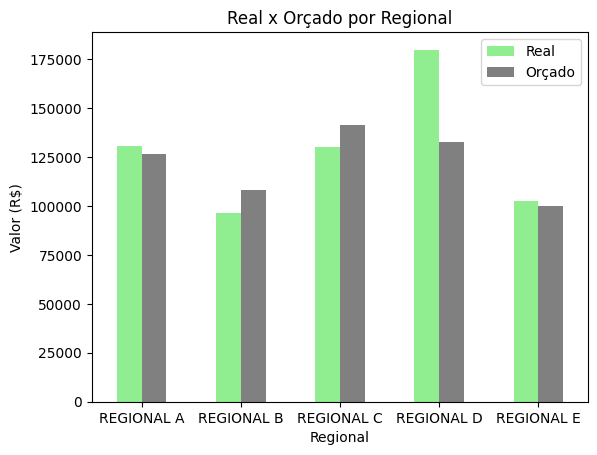

In [ ]:
df_comparacao.plot(
    x='index',
    y=['Real', 'Orçado'],
    kind='bar',
    color=['lightgreen', 'gray']
)

plt.xlabel('Regional')
plt.ylabel('Valor (R$)')
plt.title('Real x Orçado por Regional')
plt.xticks(rotation=0)

plt.show()

Ao compararmos o real com o orçado, identificamos que as **Regionais A, D e E** **estouraram o orçamento**.

**Subtarefa: (2) quais regionais possuem os maiores custos de correção por prova?**

Para descobrir quais regionais possuem os maiores custos de correção por prova, vamos calcular a média de valor por prova e agrupar por regional.

In [ ]:
custo_medio_prova = df_final.groupby('Regional')['Valor por prova'].mean().sort_values(ascending=False)
custo_medio_prova

,Valor por prova
Regional,
REGIONAL D,65.029838
REGIONAL C,52.554787
REGIONAL A,50.071489
REGIONAL E,45.737049
REGIONAL B,42.671990


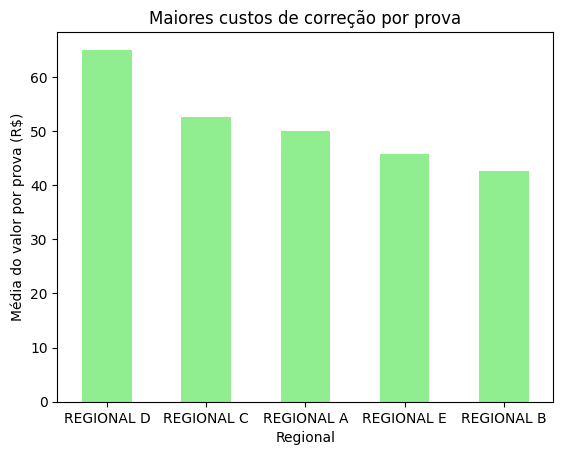

In [ ]:
custo_medio_prova.plot(kind='bar', color='lightgreen')

plt.title("Maiores custos de correção por prova")
plt.xlabel("Regional")
plt.ylabel("Média do valor por prova (R$)")
plt.xticks(rotation=0)

plt.show()

Ao compararmos os custos médios de correção por prova, identificamos uma certa distância da média do valor por prova da **Regional D** em comparação com as demais regionais. Já as outras regionais têm uma variação bem pequena entre si.

**Email ao diretor da marca**

[Email ao diretor](https://docs.google.com/document/d/1gwgnLqB4csr7M1IpJwlAgZXKcUqv5oZfOrHBd5Va-aw/edit?tab=t.0)